<a href="https://colab.research.google.com/github/surya123479/ai-product-image-generator/blob/main/sentiment_analysis_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis of Tweets using NLP & Machine Learning

## Problem Statement
Social media platforms generate large volumes of text data daily. This project classifies tweets into Positive, Negative, or Neutral sentiment using embedding-based NLP techniques.

## Objective
To build a sentiment classification system using embeddings, cosine similarity, and machine learning models.

## Dataset
- Source: Kaggle Twitter Sentiment Dataset
- Size: ~27,000 tweets
- Columns: text, sentiment

In [7]:
!pip -q install sentence-transformers xgboost wordcloud

In [8]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

In [9]:
from google.colab import files
uploaded = files.upload()

Saving tweets.csv.zip to tweets.csv.zip


In [12]:

possible_files = ["Twitter_Data.csv", "twitter_data.csv", "data.csv","tweets.csv.zip"]

file_name = None
import os
for f in possible_files:
    if f in os.listdir():
        file_name = f
        break

if file_name is None:
    raise FileNotFoundError("Upload CSV (e.g., Twitter_Data.csv) and re-run.")

df = pd.read_csv(file_name, encoding="latin-1")
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [13]:
print("Columns:", df.columns.tolist())

Columns: ['textID', 'text', 'selected_text', 'sentiment']


In [14]:

if "text" in df.columns and "sentiment" in df.columns:
    pass
elif "clean_text" in df.columns:
    df.rename(columns={"clean_text": "text"}, inplace=True)
elif "tweet" in df.columns:
    df.rename(columns={"tweet": "text"}, inplace=True)

# If sentiment not string, keep as is; else ensure name
if "sentiment" not in df.columns:
    # try common alternatives
    for alt in ["label", "target"]:
        if alt in df.columns:
            df.rename(columns={alt: "sentiment"}, inplace=True)

print(df.columns)

Index(['textID', 'text', 'selected_text', 'sentiment'], dtype='object')


In [15]:
df = df[["text", "sentiment"]].copy()
df.dropna(inplace=True)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text.strip()

df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.len() > 0]

df.head()

,text,sentiment,clean_text
0,"I`d have responded, if I were going",neutral,id have responded if i were going
1,Sooo SAD I will miss you here in San Diego!!!,negative,sooo sad i will miss you here in san diego
2,my boss is bullying me...,negative,my boss is bullying me
3,what interview! leave me alone,negative,what interview leave me alone
4,"Sons of ****, why couldn`t they put them on t...",negative,sons of why couldnt they put them on the rele...


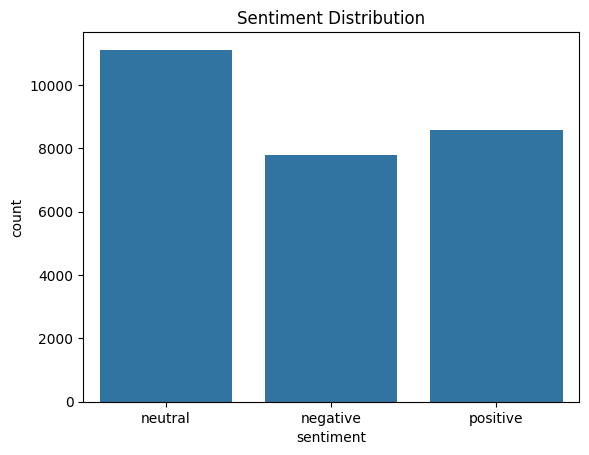

In [16]:
sns.countplot(x="sentiment", data=df)
plt.title("Sentiment Distribution")
plt.show()

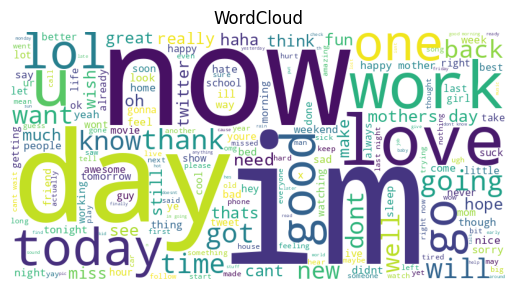

In [17]:
text_all = " ".join(df["clean_text"].astype(str))
wc = WordCloud(width=800, height=400, background_color="white").generate(text_all)

plt.imshow(wc)
plt.axis("off")
plt.title("WordCloud")
plt.show()

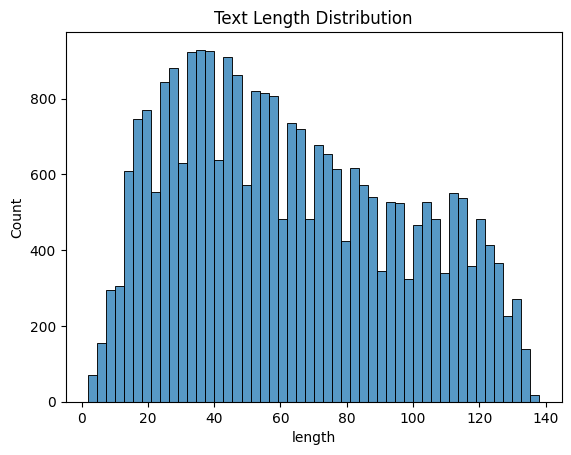

In [18]:
df["length"] = df["clean_text"].apply(len)

sns.histplot(df["length"], bins=50)
plt.title("Text Length Distribution")
plt.show()

## Embeddings

In [19]:
model = SentenceTransformer("all-MiniLM-L6-v2")

# encode in batches to avoid memory issues
embeddings = model.encode(
    df["clean_text"].tolist(),
    batch_size=64,
    show_progress_bar=True
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/430 [00:00<?, ?it/s]

## Cosine Similarity

In [20]:
sim = cosine_similarity(embeddings[0:1], embeddings[1:2])
print("Cosine Similarity:", sim)

Cosine Similarity: [[0.19323175]]


## Data Preparation

In [21]:
le = LabelEncoder()
y = le.fit_transform(df["sentiment"].astype(str))

X_train, X_test, y_train, y_test = train_test_split(
    embeddings, y, test_size=0.2, random_state=42, stratify=y
)

## XGBoost Model

In [22]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.59      0.63      1556
           1       0.60      0.71      0.65      2223
           2       0.73      0.64      0.68      1717

    accuracy                           0.66      5496
   macro avg       0.67      0.65      0.66      5496
weighted avg       0.66      0.66      0.66      5496



## Logistic Regression

In [23]:
lr = LogisticRegression(max_iter=300)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.69      0.66      0.67      1556
           1       0.63      0.69      0.66      2223
           2       0.75      0.69      0.72      1717

    accuracy                           0.68      5496
   macro avg       0.69      0.68      0.68      5496
weighted avg       0.69      0.68      0.68      5496



## Confusion Matrix

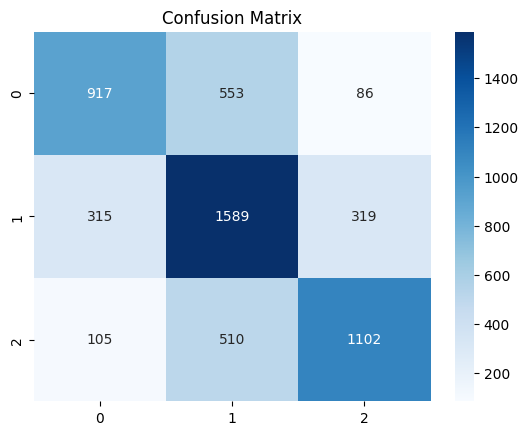

In [24]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

## Prediction Function

In [25]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    emb = model.encode([cleaned])
    pred = xgb.predict(emb)
    return le.inverse_transform(pred)[0]

## Custom Predictions

In [26]:
samples = [
    "I love this product!",
    "Worst service ever",
    "It is okay, nothing special",
    "Amazing experience!",
    "I am not happy"
]

for s in samples:
    print(s, "→", predict_sentiment(s))

I love this product! → positive
Worst service ever → negative
It is okay, nothing special → positive
Amazing experience! → neutral
I am not happy → negative


## Insights
- Dataset slightly imbalanced toward positive
- Neutral class is hardest to classify
- XGBoost outperforms Logistic Regression
- Embeddings capture semantic meaning effectively